# Importing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Dataframe and Visualisation

In [ ]:
data = pd.read_csv("../Data/cleaned_data_transformed.csv")
df = pd.DataFrame(data)

In [36]:
df

,price,city,neighbourhood,bedrooms,bathrooms,surface_area,subcategory,latitude,longitude,furnished?,property_mortgaged?,lister_type,facade,price_per_meter_square
0,720000.0,Benghazi,Qar Yunis,3.0,2.0,105.0,Apartment,32.847191,13.125021,False,False,Agent,Eastern,6857.142857
1,725000.0,Benghazi,Al Hawary,3.0,2.0,105.0,Apartment,32.778309,13.264442,False,False,Landlord,Eastern,6904.761905
2,290000.0,Benghazi,Venice,4.0,2.0,155.0,Apartment,32.763538,13.181585,False,False,Agent,Eastern,1870.967742
3,230000.0,Benghazi,Al Sayeda Aesha,4.0,2.0,160.0,Apartment,32.781060,13.078820,False,False,Landlord,Eastern,1437.500000
4,450000.0,Benghazi,Qar Yunis,2.0,1.0,120.0,Apartment,32.829285,13.102837,False,False,Landlord,Eastern,3750.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,250000.0,tripoli,Tareeq Al Mashtal,7.0,5.0,450.0,Villa,32.823380,13.127478,False,False,Agent,Western,555.555556
1967,450000.0,tripoli,Ain Zara,7.0,3.0,350.0,Villa,32.022217,20.033054,False,False,Agent,Western,1285.714286
1968,245000.0,tripoli,Al Jabs,7.0,4.0,560.0,Villa,32.837254,13.011137,False,False,Agent,Western,437.500000
1969,250000.0,tripoli,Al Sabaa,5.0,4.0,300.0,Villa,32.889301,13.185127,False,False,Agent,Western,833.333333


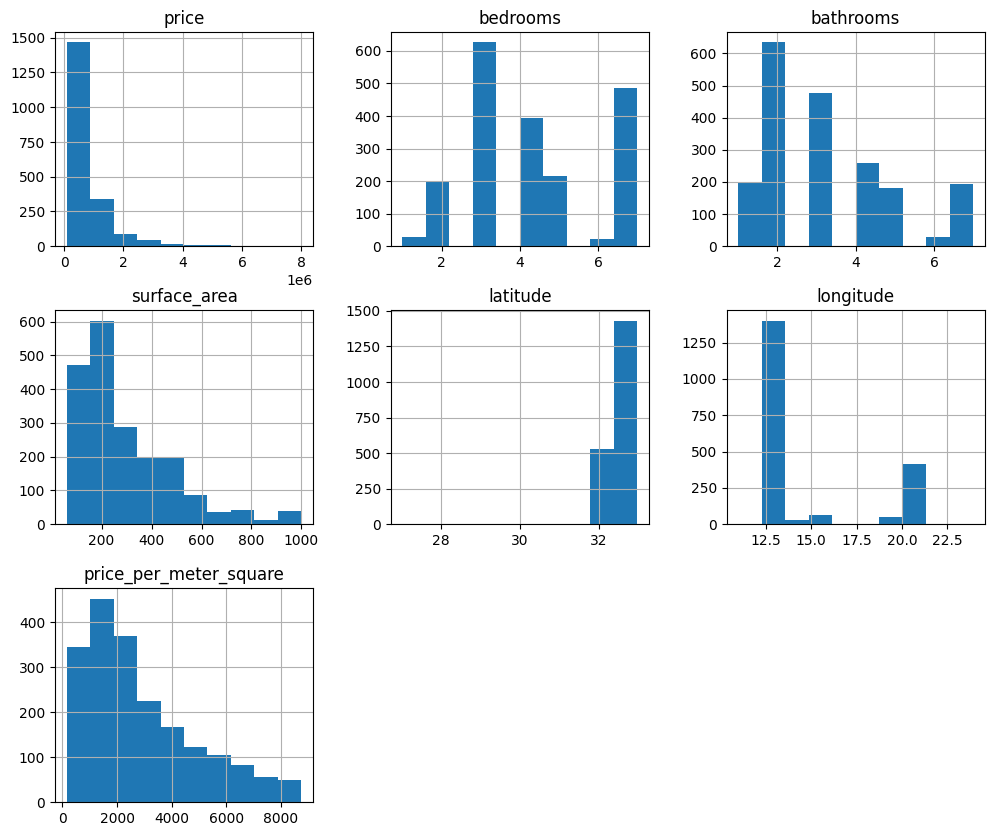

In [37]:
df.hist(figsize=(12, 10))
plt.show()

# Log Normalising Scewed Data

In [38]:
df['price'] = np.log(df['price'] + 1)
df['surface_area'] = np.log(df['surface_area'] + 1)
df['price_per_meter_square'] = np.log(df['price_per_meter_square'] + 1)

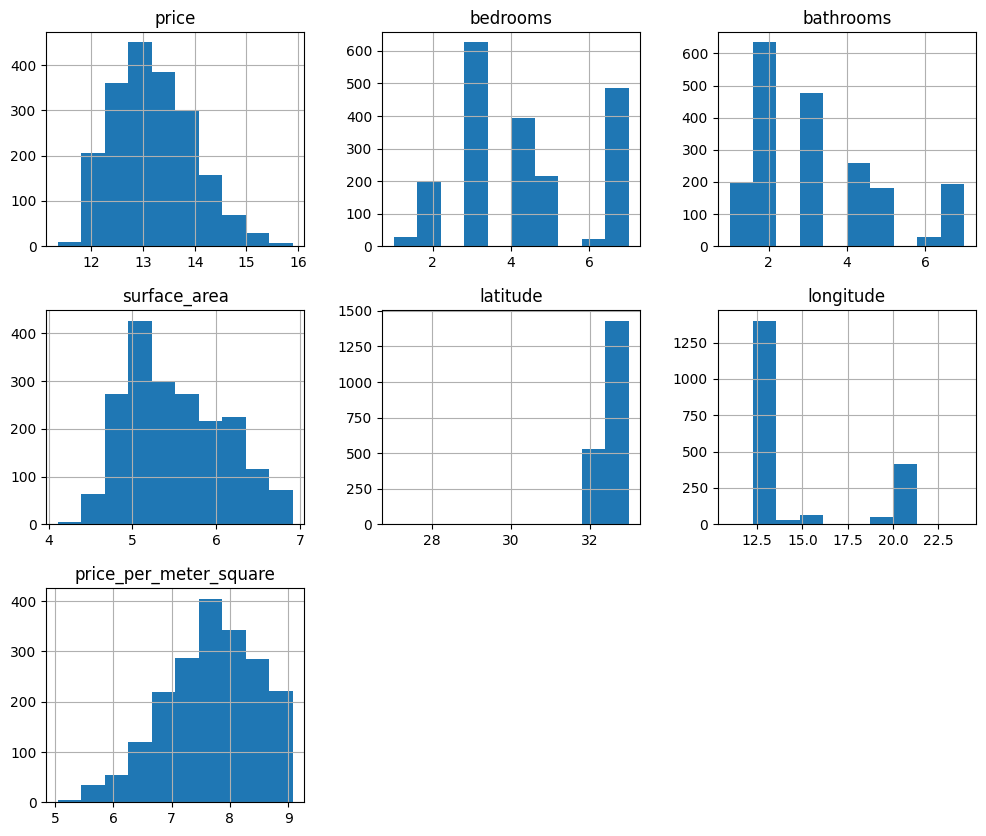

In [39]:
df.hist(figsize=(12, 10))
plt.show()

# Encoding String Columns

## Cleaning Neighbourhood and City

In [40]:
df.drop(columns=['neighbourhood'], inplace=True)

In [41]:
# 1. Define the specific mappings
specific_mapping = {'Al Zawiya': 'Zawiya'}

# 2. Define the list of cities that should become 'Other'
other_cities = [
    'Bani Walid', 'Tarhuna', 'Gharyan', 'Qasr Bin Ghashir',
    'Sabratha', 'Al Wahat', 'Jumayl', 'Sorman', 'Sirte',
    'Asbia', 'Jafara', 'Marj', 'Ajdabiya', 'Murqub', 'Al Khoms'
]

# 3. Apply the specific mapping first
df['city'] = df['city'].replace(specific_mapping)

# 4. Replace the list of 'other' cities with 'Other'
df['city'] = df['city'].replace(other_cities, 'Other')

# 5. Finally, title case everything for consistency
df['city'] = df['city'].str.title()

In [ ]:
df['city'].value_counts()

city
Tripoli     1375
Benghazi     478
Misratah      67
Other         26
Zawiya        17
Al Khoms       8
Name: count, dtype: int64

In [49]:
df['subcategory'].value_counts()

subcategory
House        747
Villa        681
Apartment    543
Name: count, dtype: int64

In [47]:
df['lister_type'].value_counts()

lister_type
Landlord    886
Agent       838
Owner       247
Name: count, dtype: int64

In [48]:
df['facade'].value_counts()

facade
Unknown      759
Eastern      305
Northern     287
Western      184
Northeast    168
Southern      91
Northwest     85
Southeast     57
Southwest     35
Name: count, dtype: int64

## Encoding

In [43]:
cities = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df[cities])

# Combine with numerical data
df_cities = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cities))
df_encoded = df.select_dtypes(exclude=['object']).join(df_cities)

In [44]:
df.head()

,price,city,bedrooms,bathrooms,surface_area,subcategory,latitude,longitude,furnished?,property_mortgaged?,lister_type,facade,price_per_meter_square
0,13.487008,Benghazi,3.0,2.0,4.663439,Apartment,32.847191,13.125021,False,False,Agent,Eastern,8.833192
1,13.493928,Benghazi,3.0,2.0,4.663439,Apartment,32.778309,13.264442,False,False,Landlord,Eastern,8.840111
2,12.577640,Benghazi,4.0,2.0,5.049856,Apartment,32.763538,13.181585,False,False,Agent,Eastern,7.534745
3,12.345839,Benghazi,4.0,2.0,5.081404,Apartment,32.781060,13.078820,False,False,Landlord,Eastern,7.271356
4,13.017005,Benghazi,2.0,1.0,4.795791,Apartment,32.829285,13.102837,False,False,Landlord,Eastern,8.229778


In [45]:
df_encoded.head()

,price,bedrooms,bathrooms,surface_area,latitude,longitude,furnished?,property_mortgaged?,price_per_meter_square,city_Al Khoms,...,lister_type_Owner,facade_Eastern,facade_Northeast,facade_Northern,facade_Northwest,facade_Southeast,facade_Southern,facade_Southwest,facade_Unknown,facade_Western
0,13.487008,3.0,2.0,4.663439,32.847191,13.125021,False,False,8.833192,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.493928,3.0,2.0,4.663439,32.778309,13.264442,False,False,8.840111,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.577640,4.0,2.0,5.049856,32.763538,13.181585,False,False,7.534745,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,12.345839,4.0,2.0,5.081404,32.781060,13.078820,False,False,7.271356,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13.017005,2.0,1.0,4.795791,32.829285,13.102837,False,False,8.229778,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
df_dropped = df_encoded.drop(columns=['price_per_meter_square'], inplace=False)

# Saving to CSV

In [57]:
df_dropped.to_csv('../Data/processed_data.csv', index=False)